# `indicator_country_year_wide_clean`: очистка и заполнение пропусков

Этот notebook посвящён таблице `indicator_country_year_wide_clean`.

Это уже почти готовый foundation для:

- фронтенда,
- country profiles,
- time-series visualizations,
- аналитики,
- storytelling.

---

## Главная цель

Собрать максимально качественную таблицу:

- без мусорных строк,
- с понятной логикой заполнения пропусков,
- с прозрачными правилами imputation,
- с флагами, где значение настоящее, а где восстановленное.

---

## Очень важный принцип

**Идеально полной таблицы без пропусков честно добиться нельзя**, если не выдумывать данные.

Можно сделать два варианта:

### 1. Консервативная витрина
- минимальное вмешательство;
- заполняем только то, что можно восстанавливать относительно надёжно.

### 2. Более полная аналитическая витрина
- допускаем разумную imputation;
- используем interpolation, forward/backward fill и fallback на региональные медианы.

Именно второй вариант мы и построим, но при этом обязательно сохраним:
- флаги imputation,
- итоговый audit по заполнению.

---

## Что мы будем делать

1. Загрузим:
   - `indicator_country_year_wide_clean.csv`
   - `dim_country_clean.csv`
   - `dim_indicator_enriched.csv`
2. Посмотрим на пропуски
3. Разделим признаки по типам заполнения
4. Построим поэтапную стратегию imputation
5. Сохраним:
   - cleaned base table
   - imputed table
   - flags table
   - coverage summary before/after

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 240)

DATA_DIR = Path("./data_exports")
OUTPUT_DIR = Path("./notebooks/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
wide = pd.read_csv(DATA_DIR / "indicator_country_year_wide_clean.csv")
dim_country = pd.read_csv(DATA_DIR / "dim_country_clean.csv")
dim_indicator = pd.read_csv(DATA_DIR / "dim_indicator_enriched.csv")

print("indicator_country_year_wide_clean:", wide.shape)
print("dim_country_clean:", dim_country.shape)
print("dim_indicator_enriched:", dim_indicator.shape)

indicator_country_year_wide_clean: (11935, 18)
dim_country_clean: (217, 5)
dim_indicator_enriched: (17, 6)


## 2. Первичный обзор таблицы

In [3]:
wide.head(10)

,country_iso3,year,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct
0,ABW,1970,44.769,65.259745,NaN,-20.169,NaN,14734.0,NaN,NaN,NaN,28.208,19.392686,-139.0,2.973,72.191147,NaN,62.413451
1,ABW,1971,44.017,64.195784,NaN,-20.500,NaN,14828.5,NaN,NaN,NaN,28.111,19.522620,-201.0,2.862,71.509228,NaN,62.928418
2,ABW,1972,43.310,62.163019,NaN,-9.305,NaN,15079.0,NaN,NaN,NaN,28.020,19.761453,431.0,2.755,69.810858,NaN,63.436488
3,ABW,1973,43.140,59.350463,NaN,-5.182,NaN,15506.5,NaN,NaN,NaN,27.888,20.155941,649.0,2.655,67.268455,NaN,63.927938
4,ABW,1974,43.121,56.602765,NaN,-3.992,NaN,15975.5,NaN,NaN,NaN,27.766,20.583889,724.0,2.573,64.769722,NaN,64.393043
5,ABW,1975,43.221,53.974314,NaN,-4.719,NaN,16442.0,NaN,NaN,NaN,27.653,21.025908,657.0,2.499,62.370171,NaN,64.822080
6,ABW,1976,43.480,51.384246,NaN,-11.441,NaN,16849.5,NaN,NaN,NaN,27.548,21.580576,260.0,2.432,60.026640,NaN,65.205326
7,ABW,1977,43.848,48.992401,NaN,-11.835,NaN,17180.5,NaN,NaN,NaN,27.445,22.234863,220.0,2.372,57.906762,NaN,65.533055
8,ABW,1978,43.956,47.008742,NaN,-12.071,NaN,17450.5,NaN,NaN,NaN,27.347,22.885302,196.0,2.312,56.157729,NaN,65.795545
9,ABW,1979,44.113,45.378540,NaN,-12.246,NaN,17650.0,NaN,NaN,NaN,27.252,23.526232,158.0,2.257,54.705191,NaN,65.983072


In [4]:
wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11935 entries, 0 to 11934
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country_iso3                      11935 non-null  object 
 1   year                              11935 non-null  int64  
 2   adolescent_fertility              11718 non-null  float64
 3   child_dependency_ratio            11880 non-null  float64
 4   contraceptive_prevalence_modern   10560 non-null  float64
 5   crude_net_migration_rate          11880 non-null  float64
 6   female_labor_force_participation  6536 non-null   float64
 7   female_population_15_49           11880 non-null  float64
 8   female_secondary_enrollment       5332 non-null   float64
 9   gdp_per_capita                    10380 non-null  float64
 10  health_expenditure_pct_gdp        4562 non-null   float64
 11  mean_age_childbearing             11880 non-null  float64
 12  medi

## 3. Присоединяем регион и income group

Это понадобится для:
- анализа coverage,
- fallback-imputation по похожим странам,
- региональных медиан по годам.

In [5]:
dim_country_work = dim_country.copy()
dim_country_work["iso3"] = dim_country_work["iso3"].astype("string").str.strip().str.upper()

wide_work = wide.copy()
wide_work["country_iso3"] = wide_work["country_iso3"].astype("string").str.strip().str.upper()

wide_work = wide_work.merge(
    dim_country_work[["iso3", "name", "region", "income_group"]],
    left_on="country_iso3",
    right_on="iso3",
    how="left"
)

wide_work = wide_work.drop(columns=["iso3"])
wide_work.head()

,country_iso3,year,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct,name,region,income_group
0,ABW,1970,44.769,65.259745,NaN,-20.169,NaN,14734.0,NaN,NaN,NaN,28.208,19.392686,-139.0,2.973,72.191147,NaN,62.413451,Aruba,Latin America & Caribbean,High income
1,ABW,1971,44.017,64.195784,NaN,-20.500,NaN,14828.5,NaN,NaN,NaN,28.111,19.522620,-201.0,2.862,71.509228,NaN,62.928418,Aruba,Latin America & Caribbean,High income
2,ABW,1972,43.310,62.163019,NaN,-9.305,NaN,15079.0,NaN,NaN,NaN,28.020,19.761453,431.0,2.755,69.810858,NaN,63.436488,Aruba,Latin America & Caribbean,High income
3,ABW,1973,43.140,59.350463,NaN,-5.182,NaN,15506.5,NaN,NaN,NaN,27.888,20.155941,649.0,2.655,67.268455,NaN,63.927938,Aruba,Latin America & Caribbean,High income
4,ABW,1974,43.121,56.602765,NaN,-3.992,NaN,15975.5,NaN,NaN,NaN,27.766,20.583889,724.0,2.573,64.769722,NaN,64.393043,Aruba,Latin America & Caribbean,High income


## 4. Список indicator columns

In [6]:
id_cols = ["country_iso3", "year", "name", "region", "income_group"]
indicator_cols = [c for c in wide_work.columns if c not in id_cols]

indicator_cols

['adolescent_fertility',
 'child_dependency_ratio',
 'contraceptive_prevalence_modern',
 'crude_net_migration_rate',
 'female_labor_force_participation',
 'female_population_15_49',
 'female_secondary_enrollment',
 'gdp_per_capita',
 'health_expenditure_pct_gdp',
 'mean_age_childbearing',
 'median_age',
 'population_change',
 'tfr',
 'total_dependency_ratio',
 'unmet_need_family_planning',
 'urban_population_pct']

## 5. Анализ пропусков до заполнения

In [7]:
missing_before = pd.DataFrame({
    "column": indicator_cols,
    "missing_count": [wide_work[c].isna().sum() for c in indicator_cols],
    "missing_ratio": [wide_work[c].isna().mean() for c in indicator_cols]
}).sort_values("missing_ratio", ascending=False)

missing_before

,column,missing_count,missing_ratio
8,health_expenditure_pct_gdp,7373,0.617763
6,female_secondary_enrollment,6603,0.553247
4,female_labor_force_participation,5399,0.452367
7,gdp_per_capita,1555,0.130289
2,contraceptive_prevalence_modern,1375,0.115207
14,unmet_need_family_planning,1375,0.115207
12,tfr,237,0.019858
0,adolescent_fertility,217,0.018182
1,child_dependency_ratio,55,0.004608
3,crude_net_migration_rate,55,0.004608


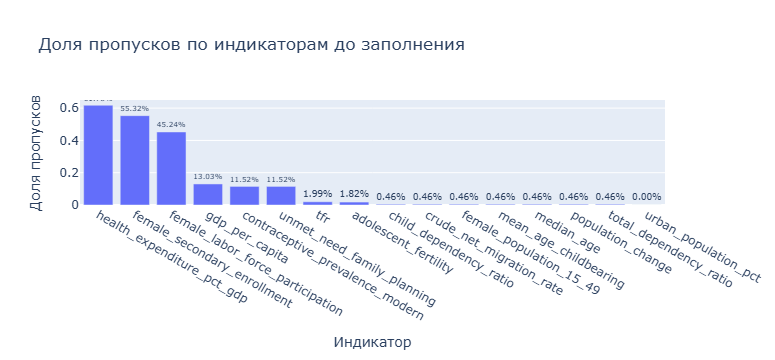

In [8]:
fig = px.bar(
    missing_before,
    x="column",
    y="missing_ratio",
    title="Доля пропусков по индикаторам до заполнения",
    text="missing_ratio"
)
fig.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig.update_layout(xaxis_title="Индикатор", yaxis_title="Доля пропусков")
fig.show()

## 6. Причины пропусков

1. **реально нет данных в источнике**  
2. **разные источники покрывают разные годы**  
3. **survey-like indicators** измеряются редко  
4. **некоторые страны маленькие / special cases**, и по ним coverage слабее  

## 7. Делим индикаторы на группы по стратегии заполнения

### Группа A — гладкие демографические временные ряды
Их можно аккуратно интерполировать по стране.

### Группа B — экономические / социальные continuous indicators
Можно интерполировать, иногда лучше в лог-шкале.

### Группа C — survey-like indicators
Их надо заполнять осторожнее.

### Группа D — volatile indicators
Заполнять тяжелее, потому что они могут резко прыгать.

In [9]:
smooth_demo_cols = [
    "tfr",
    "adolescent_fertility",
    "urban_population_pct",
    "median_age",
    "mean_age_childbearing",
    "child_dependency_ratio",
    "total_dependency_ratio",
    "female_population_15_49",
]

continuous_context_cols = [
    "female_labor_force_participation",
    "female_secondary_enrollment",
    "health_expenditure_pct_gdp",
]

log_interpolate_cols = [
    "gdp_per_capita",
]

survey_like_cols = [
    "contraceptive_prevalence_modern",
    "unmet_need_family_planning",
]

volatile_cols = [
    "crude_net_migration_rate",
    "population_change",
]

all_grouped = (
    smooth_demo_cols
    + continuous_context_cols
    + log_interpolate_cols
    + survey_like_cols
    + volatile_cols
)

sorted(set(indicator_cols) - set(all_grouped))

[]

## 8. Создаём базовую копию для заполнения и таблицу флагов

In [10]:
wide_imputed = wide_work.copy()

imputation_flags = wide_work[["country_iso3", "year"]].copy()

for col in indicator_cols:
    imputation_flags[f"{col}__was_missing"] = wide_work[col].isna()
    imputation_flags[f"{col}__imputed"] = False

## 9. Функции для imputation

In [11]:
def group_linear_interpolate(df, col, group_col="country_iso3", order_col="year", limit_direction="both"):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    df[col] = (
        df.groupby(group_col, group_keys=False)[col]
        .apply(lambda s: s.interpolate(method="linear", limit_direction=limit_direction))
    )

    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def group_log_interpolate(df, col, group_col="country_iso3", order_col="year"):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    temp = df[col].copy()
    positive_mask = temp > 0
    logged = pd.Series(np.nan, index=temp.index, dtype=float)
    logged.loc[positive_mask] = np.log(temp.loc[positive_mask])

    logged = (
        df.assign(_logged=logged)
        .groupby(group_col, group_keys=False)["_logged"]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

    restored = np.exp(logged)
    restored[~np.isfinite(restored)] = np.nan

    df[col] = df[col].where(df[col].notna(), restored)
    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def group_ffill_bfill_limited(df, col, group_col="country_iso3", order_col="year", limit=5):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    filled = (
        df.groupby(group_col, group_keys=False)[col]
        .apply(lambda s: s.ffill(limit=limit).bfill(limit=limit))
    )

    df[col] = filled
    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def fallback_region_income_year_median(df, col):
    df = df.copy()
    original_na = df[col].isna()

    group_median = (
        df.groupby(["region", "income_group", "year"])[col]
        .transform("median")
    )

    df[col] = df[col].fillna(group_median)
    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def fallback_region_year_median(df, col):
    df = df.copy()
    original_na = df[col].isna()

    group_median = (
        df.groupby(["region", "year"])[col]
        .transform("median")
    )

    df[col] = df[col].fillna(group_median)
    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def fallback_global_year_median(df, col):
    df = df.copy()
    original_na = df[col].isna()

    group_median = df.groupby("year")[col].transform("median")
    df[col] = df[col].fillna(group_median)

    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def group_linear_interpolate_inside_only(df, col, group_col="country_iso3", order_col="year"):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    df[col] = (
        df.groupby(group_col, group_keys=False)[col]
        .apply(lambda s: s.interpolate(method="linear", limit_area="inside"))
    )

    new_imputed = original_na & df[col].notna()
    return df, new_imputed


def group_ffill_only_limited(df, col, group_col="country_iso3", order_col="year", limit=2):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    df[col] = (
        df.groupby(group_col, group_keys=False)[col]
        .apply(lambda s: s.ffill(limit=limit))
    )

    new_imputed = original_na & df[col].notna()
    return df, new_imputed


def group_ffill_bfill_limited_symmetric(df, col, group_col="country_iso3", order_col="year", limit=2):
    df = df.sort_values([group_col, order_col]).copy()
    original_na = df[col].isna()

    filled = (
        df.groupby(group_col, group_keys=False)[col]
        .apply(lambda s: s.ffill(limit=limit).bfill(limit=limit))
    )

    df[col] = filled
    new_imputed = original_na & df[col].notna()
    return df, new_imputed


def fallback_region_year_median_only_missing(df, col):
    df = df.copy()
    original_na = df[col].isna()

    region_year_med = df.groupby(["region", "year"])[col].transform("median")
    df[col] = df[col].fillna(region_year_med)

    new_imputed = original_na & df[col].notna()
    return df, new_imputed


def fallback_region_income_year_median_only_missing(df, col):
    df = df.copy()
    original_na = df[col].isna()

    region_income_year_med = df.groupby(["region", "income_group", "year"])[col].transform("median")
    df[col] = df[col].fillna(region_income_year_med)

    new_imputed = original_na & df[col].notna()
    return df, new_imputed

def fallback_region_year_median_restricted(df, col, min_year=None, max_year=None):
    df = df.copy()
    original_na = df[col].isna()

    fallback = df.groupby(["region", "year"])[col].transform("median")

    mask = original_na.copy()
    if min_year is not None:
        mask &= df["year"] >= min_year
    if max_year is not None:
        mask &= df["year"] <= max_year

    df.loc[mask, col] = df.loc[mask, col].fillna(fallback[mask])

    new_imputed = original_na & df[col].notna()
    return df, new_imputed

## 10. Этап 1 — interpolation по странам для гладких демографических рядов

In [12]:
for col in smooth_demo_cols:
    wide_imputed, new_mask = group_linear_interpolate(wide_imputed, col)
    imputation_flags.loc[new_mask, f"{col}__imputed"] = True

wide_imputed[smooth_demo_cols].head()

,tfr,adolescent_fertility,urban_population_pct,median_age,mean_age_childbearing,child_dependency_ratio,total_dependency_ratio,female_population_15_49
0,2.973,44.769,62.413451,19.392686,28.208,65.259745,72.191147,14734.0
1,2.862,44.017,62.928418,19.522620,28.111,64.195784,71.509228,14828.5
2,2.755,43.310,63.436488,19.761453,28.020,62.163019,69.810858,15079.0
3,2.655,43.140,63.927938,20.155941,27.888,59.350463,67.268455,15506.5
4,2.573,43.121,64.393043,20.583889,27.766,56.602765,64.769722,15975.5


## 11. Этап 2 — interpolation для continuous context indicators

In [13]:
for col in continuous_context_cols:
    wide_imputed, new_mask = group_linear_interpolate(wide_imputed, col)
    imputation_flags.loc[new_mask, f"{col}__imputed"] = True

## 12. Этап 3 — лог-интерполяция для GDP per capita

In [14]:
for col in log_interpolate_cols:
    wide_imputed, new_mask = group_log_interpolate(wide_imputed, col)
    imputation_flags.loc[new_mask, f"{col}__imputed"] = True

## 13. Этап 4 — аккуратное заполнение survey-like indicators

Для `contraceptive_prevalence_modern` и `unmet_need_family_planning` нельзя агрессивно рисовать длинные интерполяции.  
Поэтому делаем:

1. ограниченный `ffill/bfill` внутри страны;  
2. fallback на медиану по `region × income_group × year`;  
3. потом fallback на `region × year`.

In [15]:
for col in survey_like_cols:
    wide_imputed, new_mask_1 = group_ffill_bfill_limited(wide_imputed, col, limit=5)
    imputation_flags.loc[new_mask_1, f"{col}__imputed"] = True

    wide_imputed, new_mask_2 = fallback_region_income_year_median(wide_imputed, col)
    imputation_flags.loc[new_mask_2, f"{col}__imputed"] = True

    wide_imputed, new_mask_3 = fallback_region_year_median(wide_imputed, col)
    imputation_flags.loc[new_mask_3, f"{col}__imputed"] = True

## 14. Этап 5 — volatile indicators

`crude_net_migration_rate` и `population_change` слишком шумные.  
Здесь лучше действовать осторожно:

1. короткий `ffill/bfill`;  
2. fallback на региональную медиану по году;  
3. потом глобальная медиана по году.

In [16]:
for col in volatile_cols:
    wide_imputed, new_mask_1 = group_ffill_bfill_limited(wide_imputed, col, limit=2)
    imputation_flags.loc[new_mask_1, f"{col}__imputed"] = True

    wide_imputed, new_mask_2 = fallback_region_year_median(wide_imputed, col)
    imputation_flags.loc[new_mask_2, f"{col}__imputed"] = True

    wide_imputed, new_mask_3 = fallback_global_year_median(wide_imputed, col)
    imputation_flags.loc[new_mask_3, f"{col}__imputed"] = True

## 14A. Ручная донастройка стратегий заполнения для проблемных индикаторов

После первичного визуального контроля стало видно, что для части индикаторов стандартная стратегия imputation работает слишком грубо.  
Поэтому для нескольких наиболее чувствительных колонок мы вручную применяем более осторожные правила заполнения.

In [17]:
col = "health_expenditure_pct_gdp"

wide_imputed, new_mask_1 = group_linear_interpolate_inside_only(wide_imputed, col)
imputation_flags.loc[new_mask_1, f"{col}__imputed"] = True

wide_imputed, new_mask_2 = group_ffill_only_limited(wide_imputed, col, limit=1)
imputation_flags.loc[new_mask_2, f"{col}__imputed"] = True

wide_imputed, new_mask_3 = fallback_region_year_median_restricted(
    wide_imputed,
    col,
    min_year=2000
)
imputation_flags.loc[new_mask_3, f"{col}__imputed"] = True

In [18]:
col = "female_secondary_enrollment"

wide_imputed, new_mask_1 = group_linear_interpolate_inside_only(wide_imputed, col)
imputation_flags.loc[new_mask_1, f"{col}__imputed"] = True

wide_imputed, new_mask_2 = group_ffill_only_limited(wide_imputed, col, limit=2)
imputation_flags.loc[new_mask_2, f"{col}__imputed"] = True

wide_imputed, new_mask_3 = fallback_region_year_median_restricted(
    wide_imputed,
    col,
    min_year=1995
)
imputation_flags.loc[new_mask_3, f"{col}__imputed"] = True

In [19]:
col = "contraceptive_prevalence_modern"

wide_imputed[col] = wide_work[col].copy()
imputation_flags[f"{col}__imputed"] = False

wide_imputed, new_mask_1 = group_linear_interpolate_inside_only(wide_imputed, col)
imputation_flags.loc[new_mask_1, f"{col}__imputed"] = True

wide_imputed, new_mask_2 = group_ffill_bfill_limited_symmetric(wide_imputed, col, limit=2)
imputation_flags.loc[new_mask_2, f"{col}__imputed"] = True

wide_imputed, new_mask_3 = fallback_region_year_median_only_missing(wide_imputed, col)
imputation_flags.loc[new_mask_3, f"{col}__imputed"] = True

## 15. Проверка пропусков после заполнения

In [20]:
missing_after = pd.DataFrame({
    "column": indicator_cols,
    "missing_count_after": [wide_imputed[c].isna().sum() for c in indicator_cols],
    "missing_ratio_after": [wide_imputed[c].isna().mean() for c in indicator_cols]
}).sort_values("missing_ratio_after", ascending=False)

missing_after

,column,missing_count_after,missing_ratio_after
4,female_labor_force_participation,1650,0.138249
8,health_expenditure_pct_gdp,720,0.060327
6,female_secondary_enrollment,250,0.020947
7,gdp_per_capita,165,0.013825
1,child_dependency_ratio,55,0.004608
5,female_population_15_49,55,0.004608
9,mean_age_childbearing,55,0.004608
10,median_age,55,0.004608
13,total_dependency_ratio,55,0.004608
0,adolescent_fertility,0,0.000000


In [21]:
coverage_compare = missing_before.merge(
    missing_after,
    on="column",
    how="left"
)

coverage_compare["filled_count"] = coverage_compare["missing_count"] - coverage_compare["missing_count_after"]
coverage_compare["filled_ratio_points"] = coverage_compare["missing_ratio"] - coverage_compare["missing_ratio_after"]

coverage_compare.sort_values("filled_count", ascending=False)

,column,missing_count,missing_ratio,missing_count_after,missing_ratio_after,filled_count,filled_ratio_points
0,health_expenditure_pct_gdp,7373,0.617763,720,0.060327,6653,0.557436
1,female_secondary_enrollment,6603,0.553247,250,0.020947,6353,0.532300
2,female_labor_force_participation,5399,0.452367,1650,0.138249,3749,0.314118
3,gdp_per_capita,1555,0.130289,165,0.013825,1390,0.116464
4,contraceptive_prevalence_modern,1375,0.115207,0,0.000000,1375,0.115207
5,unmet_need_family_planning,1375,0.115207,0,0.000000,1375,0.115207
6,tfr,237,0.019858,0,0.000000,237,0.019858
7,adolescent_fertility,217,0.018182,0,0.000000,217,0.018182
9,crude_net_migration_rate,55,0.004608,0,0.000000,55,0.004608
13,population_change,55,0.004608,0,0.000000,55,0.004608


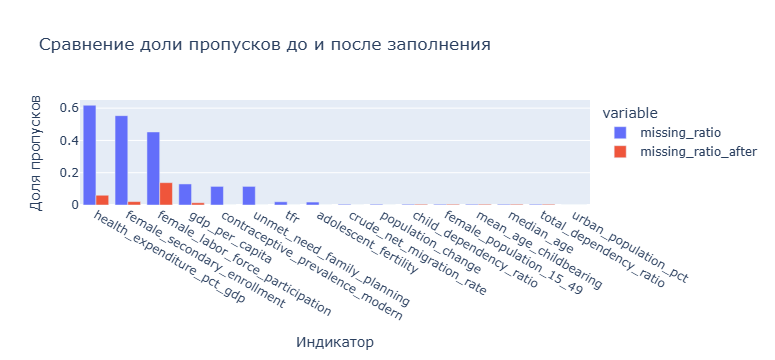

In [22]:
fig = px.bar(
    coverage_compare.sort_values("filled_ratio_points", ascending=False),
    x="column",
    y=["missing_ratio", "missing_ratio_after"],
    barmode="group",
    title="Сравнение доли пропусков до и после заполнения"
)
fig.update_layout(xaxis_title="Индикатор", yaxis_title="Доля пропусков")
fig.show()

## 16. Проверка нескольких стран после imputation

In [23]:
sample_countries = ["USA", "IND", "BRA", "AFG", "DEU"]
sample_df = wide_imputed[wide_imputed["country_iso3"].isin(sample_countries)].copy()
sample_df.head(20)

,country_iso3,year,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct,name,region,income_group
55,AFG,1970,138.511,82.255313,1.1,0.395,15.739,2515303.0,2.227090,174.930991,9.443391,29.540,16.973796,279597.0,7.400,87.257674,28.5,11.229766,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
56,AFG,1971,138.573,83.033051,1.2,-1.107,15.739,2571350.5,2.349200,174.930991,9.443391,29.560,16.841100,275483.0,7.432,88.026361,28.5,11.666036,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
57,AFG,1972,138.421,83.793719,1.3,-0.342,15.739,2629041.5,2.394310,174.930991,9.443391,29.582,16.713333,296574.0,7.453,88.775651,28.5,12.161985,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
58,AFG,1973,138.000,84.540636,1.3,-0.249,15.739,2690468.5,2.682580,174.930991,9.443391,29.601,16.591305,312033.0,7.487,89.510733,28.4,12.691692,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
59,AFG,1974,137.690,85.283247,1.5,-1.605,15.739,2752973.0,2.665100,174.930991,9.443391,29.622,16.473673,310221.0,7.526,90.243770,28.4,13.234771,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
60,AFG,1975,136.927,86.013456,1.6,-3.477,15.739,2813794.5,2.825380,174.930991,9.443391,29.644,16.360003,299434.0,7.542,90.967207,28.4,13.770838,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
61,AFG,1976,136.237,86.724977,1.7,-6.541,15.739,2870268.0,3.233040,174.930991,9.443391,29.666,16.251473,272360.0,7.561,91.674341,28.4,14.279508,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
62,AFG,1977,135.728,87.427689,1.8,-6.230,15.739,2925346.5,3.837920,174.930991,9.443391,29.686,16.146537,289451.0,7.591,92.375075,28.4,14.740395,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
63,AFG,1978,134.837,88.124316,2.0,-8.609,15.739,2979417.5,4.135550,174.930991,9.443391,29.704,16.041961,251918.0,7.599,93.065183,28.4,15.133115,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
64,AFG,1979,133.105,88.825909,2.1,-38.476,15.739,2986914.5,5.454743,174.930991,9.443391,29.728,15.934751,-163666.0,7.612,93.747130,28.4,15.437601,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income


## 18A. Дополнительная визуальная проверка качества заполнения

Чтобы не распыляться на слишком много повторяющихся графиков, в этом разделе мы анализируем только индикаторы с наибольшей долей пропусков до заполнения.

Это логично, потому что именно они были самыми проблемными для итоговой country-year витрины.  
Для них мы проверяем четыре вещи:

1. насколько снизилась доля пропусков;
2. насколько сильно изменились распределения;
3. сохранилась ли форма временных рядов;
4. не выглядит ли заполнение слишком агрессивным или искусственным.

### Шаг 1. Выбираем единый набор top-missing indicators

In [24]:
TOP_MISSING_N = 6

top_missing_df = (
    missing_before
    .sort_values("missing_ratio", ascending=False)
    .head(TOP_MISSING_N)
    .copy()
)

top_missing_cols = top_missing_df["column"].tolist()
top_missing_df

,column,missing_count,missing_ratio
8,health_expenditure_pct_gdp,7373,0.617763
6,female_secondary_enrollment,6603,0.553247
4,female_labor_force_participation,5399,0.452367
7,gdp_per_capita,1555,0.130289
2,contraceptive_prevalence_modern,1375,0.115207
14,unmet_need_family_planning,1375,0.115207


### График 1. Доля пропусков до и после заполнения

Здесь смотрим только на те индикаторы, которые были самыми проблемными до imputation.

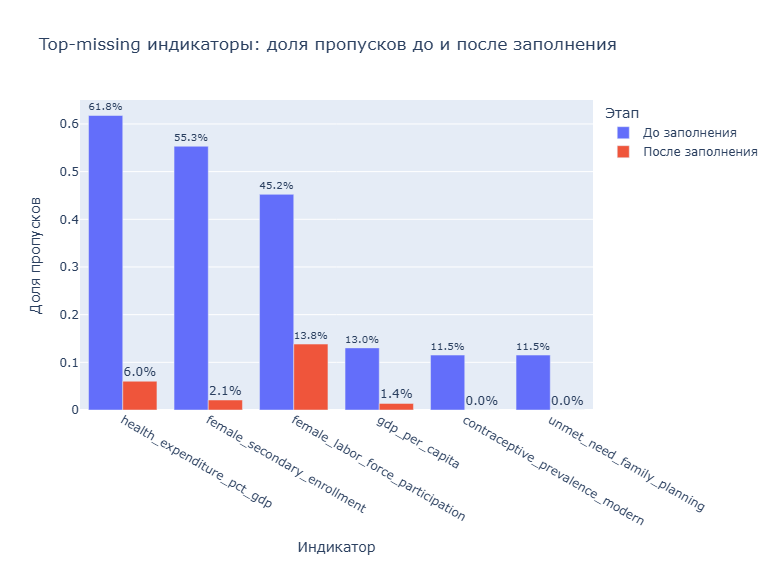

In [25]:
coverage_top = coverage_compare[
    coverage_compare["column"].isin(top_missing_cols)
].copy()

coverage_long = coverage_top.melt(
    id_vars="column",
    value_vars=["missing_ratio", "missing_ratio_after"],
    var_name="stage",
    value_name="missing_ratio_value"
)

coverage_long["stage"] = coverage_long["stage"].map({
    "missing_ratio": "До заполнения",
    "missing_ratio_after": "После заполнения"
})

fig = px.bar(
    coverage_long,
    x="column",
    y="missing_ratio_value",
    color="stage",
    barmode="group",
    title="Top-missing индикаторы: доля пропусков до и после заполнения",
    text="missing_ratio_value"
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside")

fig.update_layout(
    xaxis_title="Индикатор",
    yaxis_title="Доля пропусков",
    legend_title="Этап",
    height=550,
    width=1100
)

fig.show()

### График 2. Насколько уменьшилась доля пропусков

Этот график показывает уже не абсолютный уровень пропусков, а эффект заполнения.

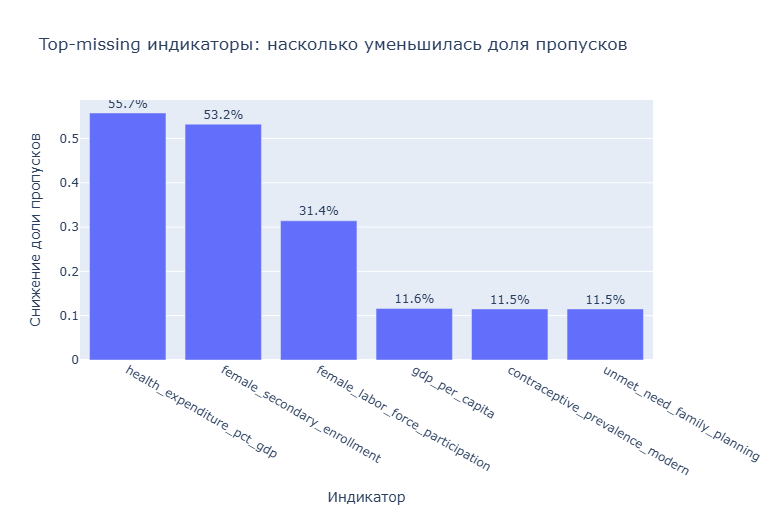

In [26]:
fig = px.bar(
    coverage_top.sort_values("filled_ratio_points", ascending=False),
    x="column",
    y="filled_ratio_points",
    title="Top-missing индикаторы: насколько уменьшилась доля пропусков",
    text="filled_ratio_points"
)

fig.update_traces(texttemplate="%{text:.1%}", textposition="outside")

fig.update_layout(
    xaxis_title="Индикатор",
    yaxis_title="Снижение доли пропусков",
    height=500,
    width=1000
)

fig.show()

### График 3. Распределения до и после заполнения

Здесь проверяем, не исказились ли распределения после imputation.

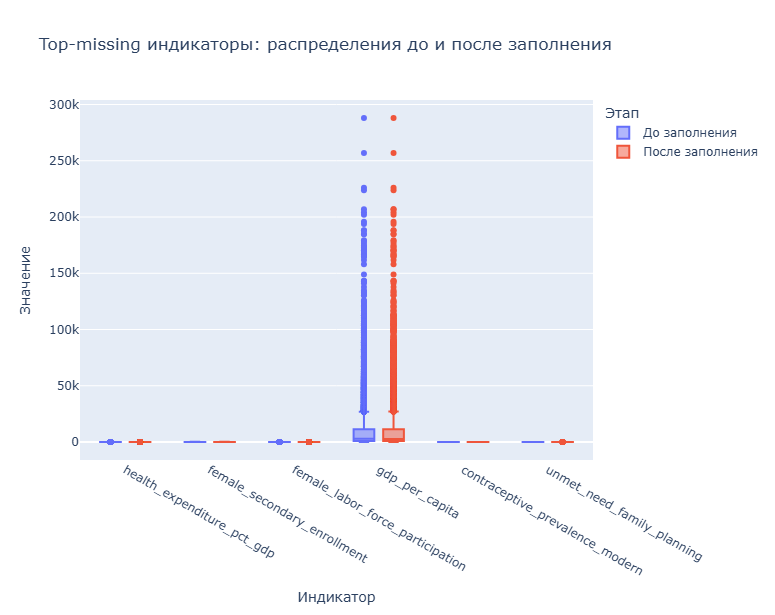

In [27]:
dist_frames = []

for col in top_missing_cols:
    before_part = pd.DataFrame({
        "indicator": col,
        "stage": "До заполнения",
        "value": wide_work[col]
    })

    after_part = pd.DataFrame({
        "indicator": col,
        "stage": "После заполнения",
        "value": wide_imputed[col]
    })

    dist_frames.append(before_part)
    dist_frames.append(after_part)

dist_compare = pd.concat(dist_frames, ignore_index=True)

fig = px.box(
    dist_compare.dropna(),
    x="indicator",
    y="value",
    color="stage",
    title="Top-missing индикаторы: распределения до и после заполнения"
)

fig.update_layout(
    xaxis_title="Индикатор",
    yaxis_title="Значение",
    legend_title="Этап",
    height=600,
    width=1100
)

fig.show()

### График 4. Мировые медианные временные ряды до и после заполнения

Это главная sanity check для imputation.  
Здесь мы смотрим, сохранилась ли форма рядов и не стало ли заполнение слишком искусственным.

Для каждого индикатора используется собственный масштаб по оси Y, чтобы большие показатели вроде `gdp_per_capita` не "давили" остальные.

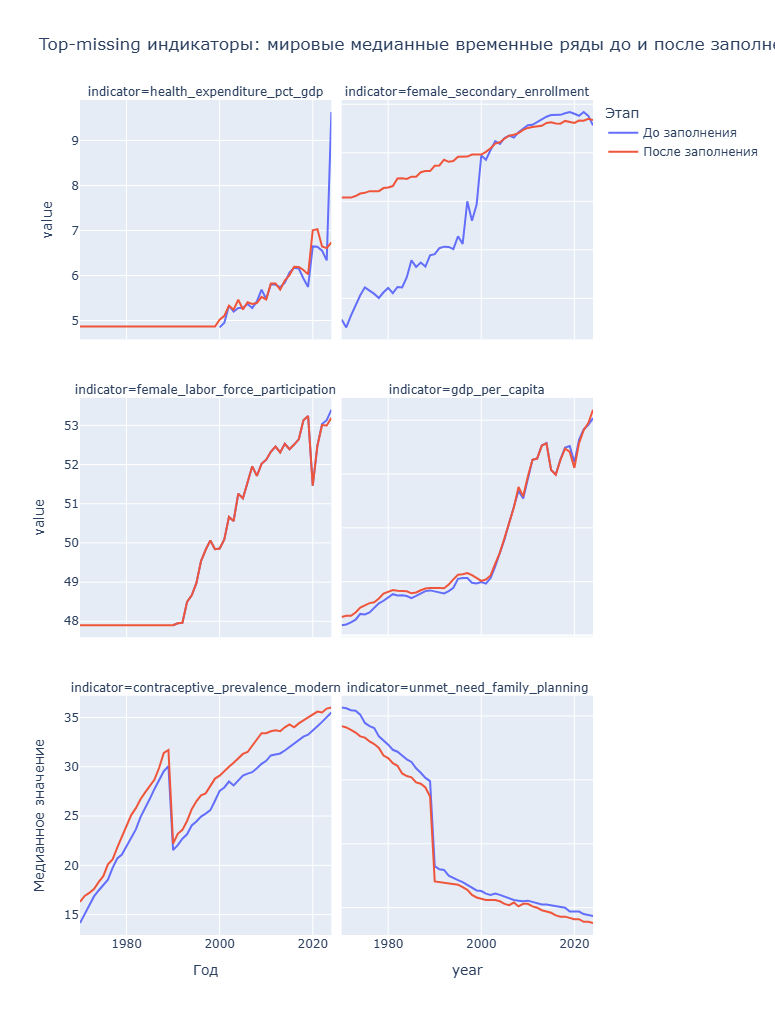

In [28]:
trend_frames = []

for col in top_missing_cols:
    before_trend = (
        wide_work.groupby("year")[col]
        .median()
        .reset_index()
        .assign(indicator=col, stage="До заполнения")
        .rename(columns={col: "value"})
    )

    after_trend = (
        wide_imputed.groupby("year")[col]
        .median()
        .reset_index()
        .assign(indicator=col, stage="После заполнения")
        .rename(columns={col: "value"})
    )

    trend_frames.append(before_trend)
    trend_frames.append(after_trend)

trend_compare = pd.concat(trend_frames, ignore_index=True)

fig = px.line(
    trend_compare,
    x="year",
    y="value",
    color="stage",
    facet_col="indicator",
    facet_col_wrap=2,
    title="Top-missing индикаторы: мировые медианные временные ряды до и после заполнения"
)

fig.for_each_yaxis(lambda axis: axis.update(matches=None))

fig.update_layout(
    xaxis_title="Год",
    yaxis_title="Медианное значение",
    legend_title="Этап",
    height=1000,
    width=1100
)

fig.show()

## 18B. Как интерпретировать этот блок

После хорошего imputation мы ожидаем увидеть:

1. заметное снижение доли пропусков;
2. распределения до и после должны быть похожи по форме;
3. временные ряды должны сохранить общую траекторию;
4. imputation не должна превращать данные в полностью искусственные гладкие линии.

Если какой-то индикатор:
- слишком сильно поменял распределение;
- слишком резко оторвался от исходного ряда;
- или выглядит подозрительно "дорисованным",

значит именно для него стратегию заполнения надо ослабить.

## 19. Формируем финальную витрину

Убираем текстовые dimension-колонки в отдельный конец и сохраняем table, пригодную для downstream use.

In [29]:
atlas_country_year_imputed = wide_imputed.copy()

ordered_cols = [
    "country_iso3",
    "year",
    "name",
    "region",
    "income_group",
] + indicator_cols

atlas_country_year_imputed = atlas_country_year_imputed[ordered_cols].copy()
atlas_country_year_imputed.head()

,country_iso3,year,name,region,income_group,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct
0,ABW,1970,Aruba,Latin America & Caribbean,High income,44.769,65.259745,24.1,-20.169,NaN,14734.0,98.64743,6767.559229,NaN,28.208,19.392686,-139.0,2.973,72.191147,22.00,62.413451
1,ABW,1971,Aruba,Latin America & Caribbean,High income,44.017,64.195784,24.8,-20.500,NaN,14828.5,98.64743,6767.559229,NaN,28.111,19.522620,-201.0,2.862,71.509228,21.70,62.928418
2,ABW,1972,Aruba,Latin America & Caribbean,High income,43.310,62.163019,25.7,-9.305,NaN,15079.0,98.64743,6767.559229,NaN,28.020,19.761453,431.0,2.755,69.810858,21.45,63.436488
3,ABW,1973,Aruba,Latin America & Caribbean,High income,43.140,59.350463,26.6,-5.182,NaN,15506.5,98.64743,6767.559229,NaN,27.888,20.155941,649.0,2.655,67.268455,21.20,63.927938
4,ABW,1974,Aruba,Latin America & Caribbean,High income,43.121,56.602765,27.5,-3.992,NaN,15975.5,98.64743,6767.559229,NaN,27.766,20.583889,724.0,2.573,64.769722,21.00,64.393043


## 21. Сохранение результатов

In [31]:
atlas_country_year_imputed.to_csv(OUTPUT_DIR / "atlas_country_year_imputed.csv", index=False)
imputation_flags.to_csv(OUTPUT_DIR / "atlas_country_year_imputation_flags.csv", index=False)
coverage_compare.to_csv(OUTPUT_DIR / "atlas_country_year_missing_before_after.csv", index=False)

print("Файлы сохранены в:", OUTPUT_DIR)

Файлы сохранены в: notebooks\eda_outputs


## 22. Итоговые выводы

После этого notebook у нас есть:

- cleaned + imputed country-year table
- прозрачные правила заполнения
- флаги, где значение было восстановлено
- summary до/после imputation

Это уже хорошая основа для:
- фронтенда
- storytelling
- аналитики
- country cards
- фильтров и time-series views